In [1]:
from math import ceil
import h5py, numpy as np, matplotlib.pyplot as plt

In [2]:
# Velocities: [m/s]
# Density: [kg/m^3]
data_numpy = np.load('/home/brandof/Documents/diff/notebooks/AVO/data/data_numpy/elastic_prams_mod.npy')

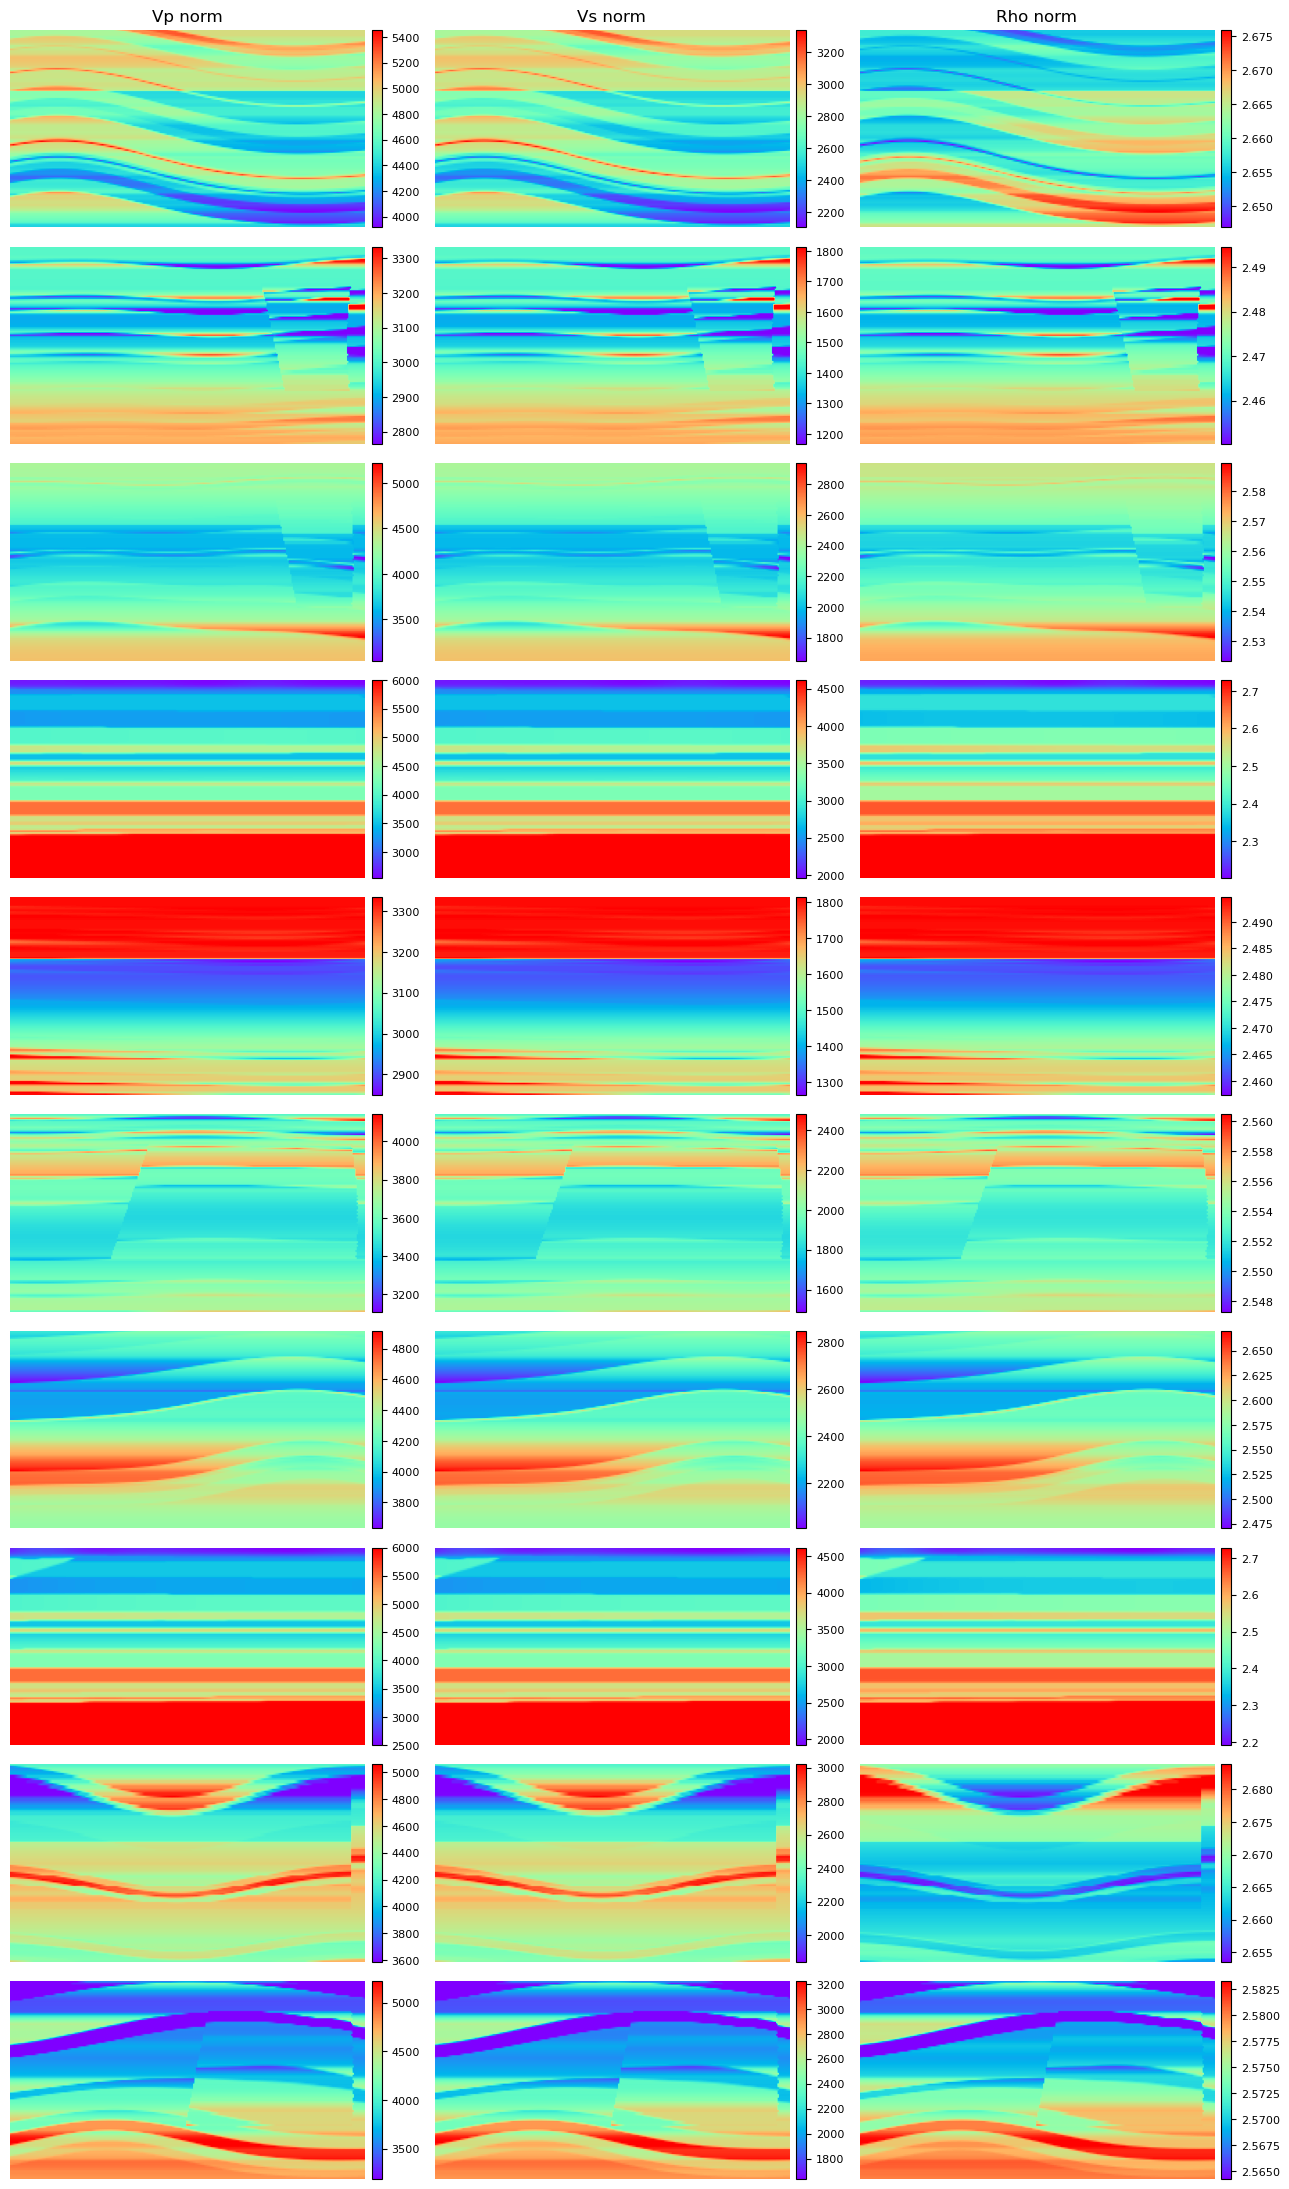

In [6]:
import numpy as np
import matplotlib.pyplot as plt
samples_np = data_numpy
# ----------------------------
# Input: samples_np (N, H, W, C)
# ----------------------------
assert samples_np.ndim == 4
assert samples_np.shape[-1] == 3

N, H, W, C = samples_np.shape

# --- Visualization parameters ---
vmin, vmax = -1, 1
cmap = "rainbow"

# --- Randomly select samples ---
n_samples = 10
idx = np.random.choice(N, size=n_samples, replace=False)

# --- Column titles ---
col_titles = ["Vp norm", "Vs norm", "Rho norm"]

# --- Create figure ---
fig, axes = plt.subplots(
    nrows=n_samples,
    ncols=3,
    figsize=(13, 2.2 * n_samples),
    squeeze=False
)

# ----------------------------
# Plot
# ----------------------------
for i, k in enumerate(idx):        # rows → random samples
    for j in range(3):             # cols → channels
        ax = axes[i, j]

        im = ax.imshow(
            samples_np[k, :, :, j],   # (H, W)
            cmap=cmap,
            aspect="auto"
        )

        ax.axis("off")

        # Titles only on first row
        if i == 0:
            ax.set_title(col_titles[j], fontsize=12)

        # Colorbar per subplot
        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.035,
            pad=0.02
        )
        cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


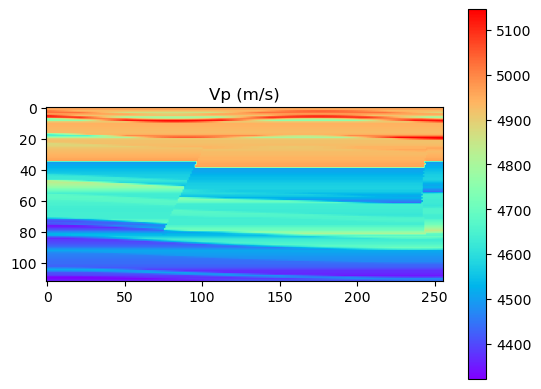

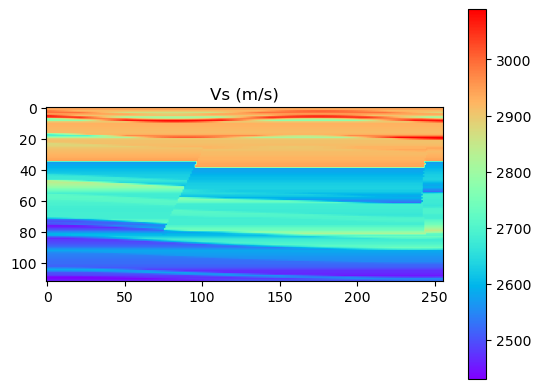

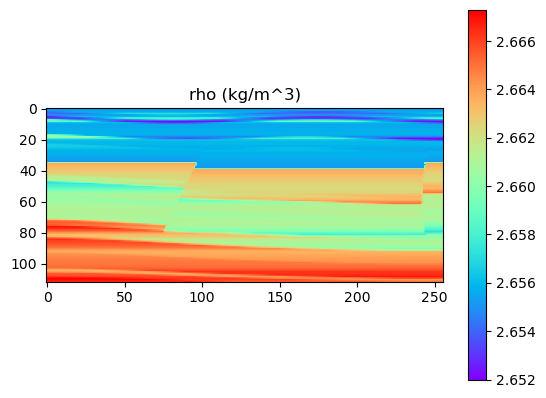

In [3]:
sample = 130
plt.imshow(data_numpy[sample,:,:,0], cmap='rainbow')
plt.title('Vp (m/s)')
plt.colorbar()
plt.show()
plt.imshow(data_numpy[sample,:,:,1], cmap='rainbow')
plt.title('Vs (m/s)')
plt.colorbar()
plt.show()
plt.imshow(data_numpy[sample,:,:,2], cmap='rainbow')
plt.title('rho (kg/m^3)')
plt.colorbar()
plt.show()


In [ ]:
import torch
import torch.nn.functional as F

# x: (2000, 112, 256, 3) e.g. numpy array or torch tensor
xtorch = torch.as_tensor(data_numpy)  # if already torch, this is fine

# 1) NHWC -> NCHW
xtorch = xtorch.permute(0, 3, 1, 2).contiguous()  # (2000, 3, 112, 256)

# 2) Upsample height to 128 (keep width 256)
xtorch_up = F.interpolate(xtorch, size=(128, 256), mode="bilinear", align_corners=False)

data_numpy_upsample = xtorch_up.numpy()

print(data_numpy.shape, data_numpy_upsample.shape)  # (2000, 3, 112, 256) -> (2000, 3, 128, 256)

# Save upsampled and permuted dataset:
# np.save('/home/brandof/Documents/diff/notebooks/AVO/data/data_numpy/elastic_data_upsample.npy', data_numpy_upsample)


(2000, 112, 256, 3) (2000, 3, 128, 256)


In [ ]:
# sample = 400
# plt.imshow(data_numpy_upsample[sample,0,:,:], cmap='rainbow')
# plt.title('Vp (m/s)')
# plt.colorbar()
# plt.show()
# plt.imshow(data_numpy_upsample[sample,1,:,:], cmap='rainbow')
# plt.title('Vs (m/s)')
# plt.colorbar()
# plt.show()
# plt.imshow(data_numpy_upsample[sample,2,:,:], cmap='rainbow')
# plt.title('rho (kg/m^3)')
# plt.colorbar()
# plt.show()


### Load the h5 file dataset and check :

In [2]:
# ---- CONFIG ----
H5_PATH = "/home/brandof/Documents/diff/notebooks/AVO/data/datah5/elastic_data_upsample_lognorm.h5"
DATASET_NAME = "train"
N_SAMPLES_TO_PLOT = 20
RANDOM_SEED = 42
CMAP = "rainbow"  # good for [-1, 1]


In [3]:
rng = np.random.default_rng(RANDOM_SEED)

with h5py.File(H5_PATH, "r") as f:
    dset = f[DATASET_NAME]
    N, C, H, W = dset.shape

    print("Dataset shape:", dset.shape)
    print("dtype:", dset.dtype)

    assert C == 3
    assert (H, W) == (128, 256)


Dataset shape: (2000, 3, 128, 256)
dtype: float32


In [4]:
idx = rng.choice(N, size=N_SAMPLES_TO_PLOT, replace=False)
print("Random sample indices:", idx)

Random sample indices: [1533 1431  400 1943 1678 1517  255  176 1298 1024  859  170  900 1705
  187 1466 1568  870 1386 1048]


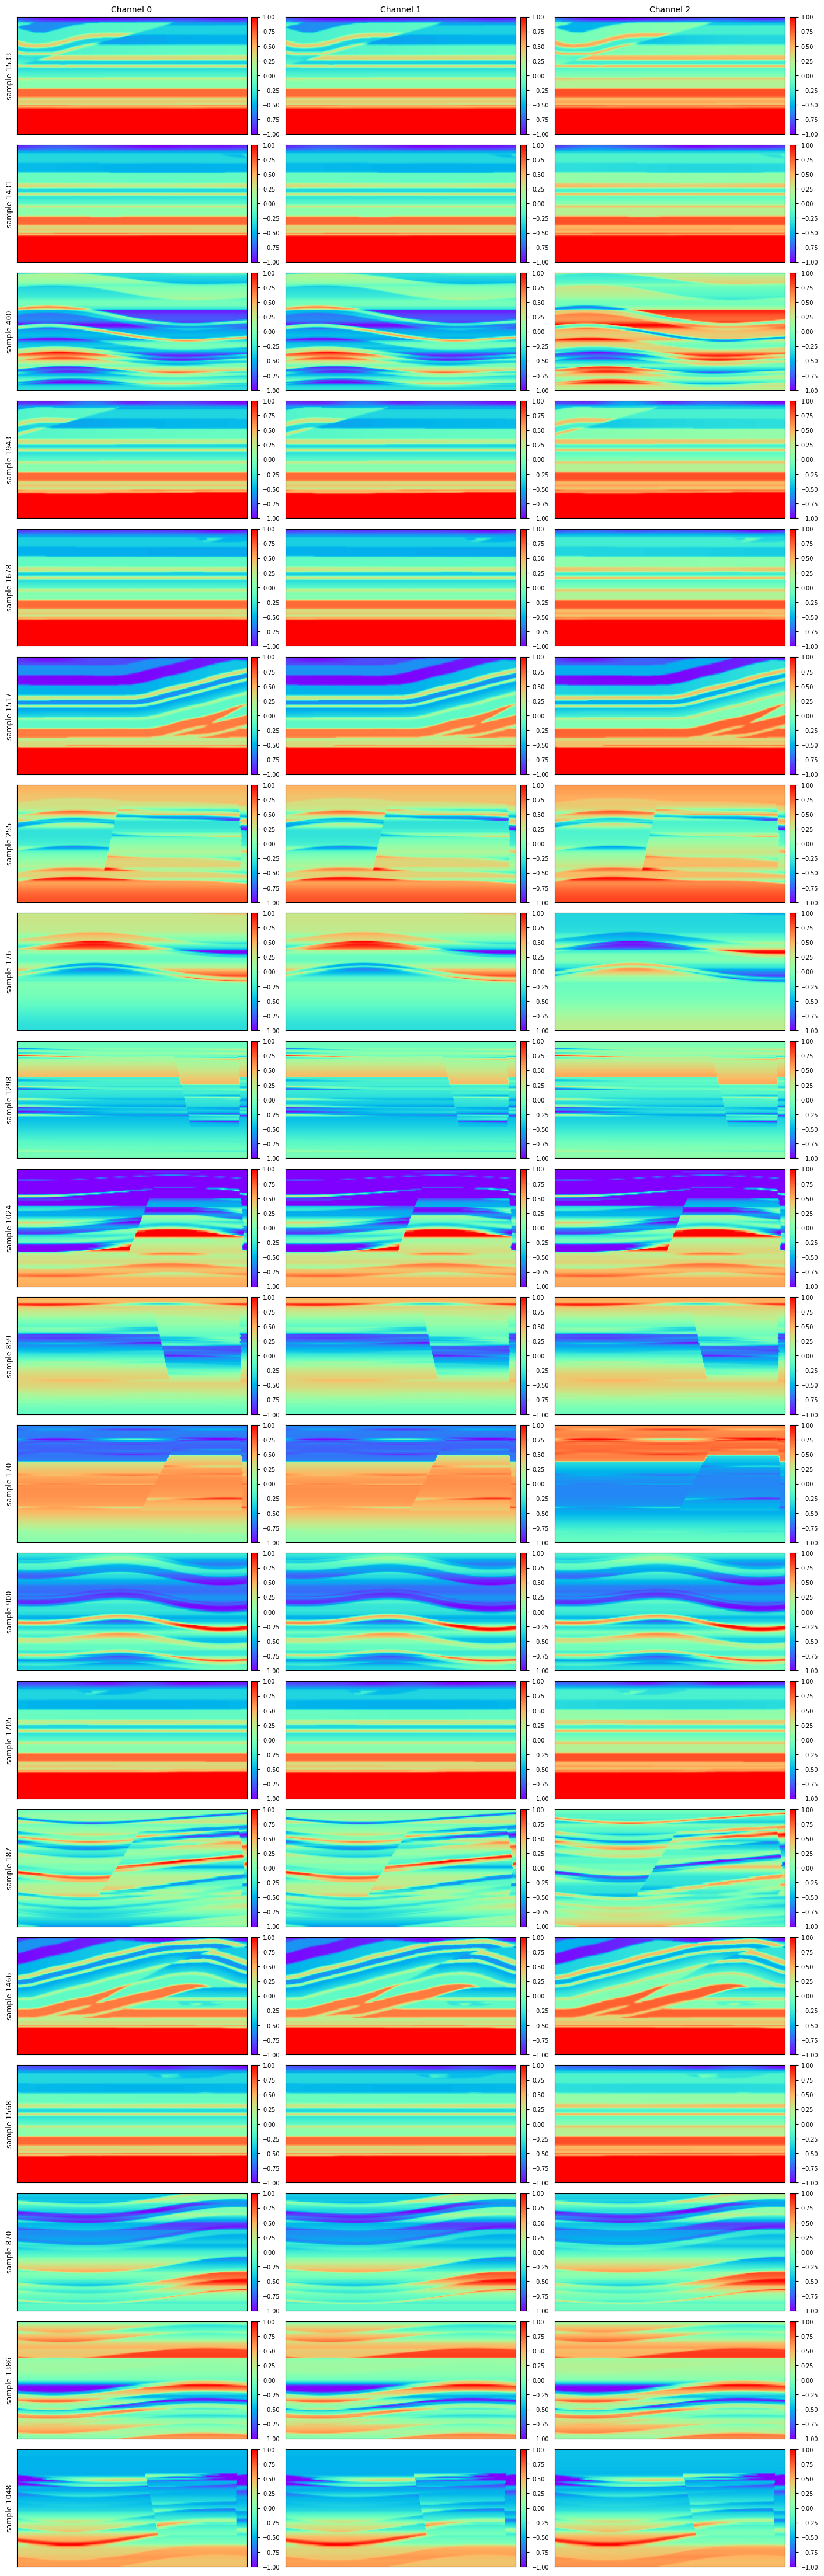

In [6]:
with h5py.File(H5_PATH, "r") as f:
    dset = f[DATASET_NAME]

    fig, axes = plt.subplots(
        nrows=N_SAMPLES_TO_PLOT,
        ncols=3,
        figsize=(14, 2.2 * N_SAMPLES_TO_PLOT),
        constrained_layout=True,
    )

    if N_SAMPLES_TO_PLOT == 1:
        axes = axes[None, :]

    for r, i in enumerate(idx):
        x = dset[i]  # (3, 128, 256)

        for c in range(3):
            ax = axes[r, c]
            im = ax.imshow(
                x[c],
                cmap=CMAP,
                vmin=-1.0,
                vmax=1.0,
                aspect="auto",
            )

            if r == 0:
                ax.set_title(f"Channel {c}", fontsize=10)

            if c == 0:
                ax.set_ylabel(f"sample {i}", fontsize=9)

            ax.set_xticks([])
            ax.set_yticks([])

            # ---- individual colorbar ----
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            cbar.ax.tick_params(labelsize=7)

    plt.show()
